# Link Video:
* https://youtu.be/KzycLSBJY6g
* https://drive.google.com/file/d/1DEn0uqqaHCMzwoir7APAfpnmAYpQEzZq/view?usp=sharing

# Almayra Edgina Rahma 2802460930

# Soal

Anda adalah seorang Data Scientist di suatu perusahaan. Tugas kalian
adalah membuat model Artificial Neural Network (ANN) berdasarkan dataset anda:
• 1A – membuat model yang dapat memperkirakan hasil panen tanaman pertanian pada perusahaan agrikultur.
Satuan yang digunakan dalam data adalah “hg/ha”.
• 1B – membuat model yang dapat menilai harga penjualan mobil bekas pada anak perusahaan dealer otomotif.
Harga yang diberikan adalah dalam USD.
Download dataset yang telah disediakan kerjakan task berikut ini.

a. [LO2 – 5 Points] Lakukan Exploratory Data Analysis (EDA) untuk memahami dan mengidentifikasi
masalah pada dataset anda. Lakukan pre-processing pada dataset anda sesuai dengan hasil EDA anda,
termasuk memisahkan dataset anda menjadi train, val, dan test dengan proporsi 70:10:20.

b. [LO1, LO2, LO3, & LO4 – 5 Points] Buatlah 1 baseline model. Semua hidden layer wajib
menggunakan activation function bernama ReLU dan memiliki jumlah neuron minimal 2 kali lipat dari
dimensi input data. Model anda harus memiliki minimal 2 hidden layer. Lakukan training pada model
tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

c. [LO1, LO2, LO3, & LO4 – 5 Points] Lakukan modifikasi pada model anda. Anda dapat mengubah
jumlah neuron dan layer ataupun activation function dari hidden layer. Anda juga dapat melakukan
hyperparameter fine-tuning pada model anda. Lakukan training pada modifikasi model anda dan
jelaskan alasan modifikasi yang anda lakukan.

d. [LO2, LO3, & LO4 – 10 Points] Lakukan evaluasi pada 2 model yang sudah anda buat menggunakan
minimal 3 evaluation metrics, lalu bandingkan, analisis, dan simpulkan hasilnya.

e. [LO1, LO2, & LO3 – 5 Points] Buatlah video presentasi yang menjelaskan langkah-langkah
pengerjaan anda serta hasil analisis anda dengan durasi maksimal 12 menit.

In [1]:
import pandas as pd

df = pd.read_parquet('1B.parquet')
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [2]:
df['torque'].head(20)

,torque
0,114Nm@ 4000rpm
1,330Nm@ 1800rpm
2,110Nm@ 4800rpm
3,200Nm@ 1750rpm
4,115Nm@ 4000rpm
5,360Nm@ 2000rpm
6,"145@ 4,100(kgm@ rpm)"
7,112Nm@ 4000rpm
8,200Nm@ 1750rpm
9,72Nm@ 4386rpm


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

In [4]:
df.shape

(2000, 18)

In [5]:
df.describe()

,Sales_ID,year,selling_price,km_driven,engine,max_power,seats
count,2000.000000,2000.000000,1998.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,4094.438500,2014.544000,6500.861947,68850.914500,1463.207500,91.872012,5.40800
std,2365.032531,22.593966,8322.011983,50097.963956,500.728476,36.126674,0.94973
min,1.000000,1999.000000,350.000000,0.000000,624.000000,-100.000000,4.00000
25%,2009.500000,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.00000
50%,4070.500000,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.00000
75%,6198.500000,2017.000000,6750.000000,90041.250000,1582.000000,102.000000,5.00000
max,8127.000000,3011.000000,100000.000000,475000.000000,3604.000000,400.000000,14.00000


In [6]:
df=df.drop(columns=['Sales_ID'])

# Preprocessing

In [7]:
df = df.dropna()
df = df.reset_index(drop=True)

In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)

data torque punya format yang tidak wajar, harusnya bisa dipisah jadi 2 kolom Nm dan Rpm dengan regex, tp periksa apa sudah konsisten

In [10]:
regex_check = df[~df['torque'].str.contains(r'Nm.*rpm|kgm.*rpm', case=False, na=False)]
print(regex_check[['torque']])

                torque
68               400Nm
115              400Nm
326   190Nm@ 2000-3000
346              400Nm
533      135.4Nm@ 2500
538              400Nm
846              400Nm
851              400Nm
996              400Nm
1093             400Nm
1581             400Nm
1657             400Nm
1717             400Nm
1788             400Nm


In [11]:
len(regex_check)

14

In [12]:
df['torque']

,torque
0,114Nm@ 4000rpm
1,330Nm@ 1800rpm
2,110Nm@ 4800rpm
3,200Nm@ 1750rpm
4,115Nm@ 4000rpm
...,...
1993,171.6Nm@ 1500-4000rpm
1994,320Nm@ 1800-2800rpm
1995,113Nm@ 4200rpm
1996,224Nm@ 4000rpm


In [13]:
import re
import numpy as np
import pandas as pd

def clean_torque(text):
    #hilangin koma, spasi, ubah ke huruf kecil
    text = str(text).lower().replace(',', '')

    #ambil angka yg muncul
    torque_match = re.search(r'(\d+\.?\d*)', text)
    torque = float(torque_match.group(1)) if torque_match else np.nan

    #klo kgm convert dulu
    if 'kgm' in text and pd.notna(torque):
        torque = torque * 9.80665

    #ekstrak rpm setelah lambang @ dan cek bila dikasi range dgn lambang -
    range_match = re.search(r'(?:@|at)[^\d]*(\d+)[-\s~]+(\d+)', text)

    if range_match:
        rpm = (float(range_match.group(1)) + float(range_match.group(2))) / 2
    else:
        #klo bukan range maka ambil angkanya aja
        single_match = re.search(r'(?:@|at)[^\d]*(\d+)', text)
        if single_match:
            rpm = float(single_match.group(1))
        else:
            #kli tidak ada @ maka cari lambang rpm
            rpm_fallback = re.search(r'(\d+)\s*rpm', text)
            rpm = float(rpm_fallback.group(1)) if rpm_fallback else np.nan

    return pd.Series([torque, rpm])

# pisah jadi 2 dataframe
df[['torque_Nm', 'rpm_val']] = df['torque'].apply(clean_torque)

In [14]:
df[['torque_Nm', 'rpm_val']].head()

,torque_Nm,rpm_val
0,114.0,4000.0
1,330.0,1800.0
2,110.0,4800.0
3,200.0,1750.0
4,115.0,4000.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 1997
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1996 non-null   object 
 1   year               1996 non-null   int64  
 2   selling_price      1996 non-null   float64
 3   km_driven          1996 non-null   int64  
 4   Region             1996 non-null   object 
 5   State or Province  1996 non-null   object 
 6   City               1996 non-null   object 
 7   fuel               1996 non-null   object 
 8   seller_type        1996 non-null   object 
 9   transmission       1996 non-null   object 
 10  owner              1996 non-null   object 
 11  mileage            1996 non-null   object 
 12  engine             1996 non-null   int64  
 13  max_power          1996 non-null   float64
 14  torque             1996 non-null   object 
 15  seats              1996 non-null   int64  
 16  sold               1996 non-n

In [16]:
df = df.drop(columns=['torque'])

## Cek Konsistensi Tipe Data


mileage harusnya string

In [17]:
#x_train['mileage']=x_train['mileage'].astype(np.float64)

ada data anomali yg membuat jd datatype object

In [18]:
df['mileage'] = df['mileage'].str.replace(',', '.', regex=False).astype(float)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1996 entries, 0 to 1997
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1996 non-null   object 
 1   year               1996 non-null   int64  
 2   selling_price      1996 non-null   float64
 3   km_driven          1996 non-null   int64  
 4   Region             1996 non-null   object 
 5   State or Province  1996 non-null   object 
 6   City               1996 non-null   object 
 7   fuel               1996 non-null   object 
 8   seller_type        1996 non-null   object 
 9   transmission       1996 non-null   object 
 10  owner              1996 non-null   object 
 11  mileage            1994 non-null   float64
 12  engine             1996 non-null   int64  
 13  max_power          1996 non-null   float64
 14  seats              1996 non-null   int64  
 15  sold               1996 non-null   object 
 16  torque_Nm          1996 non-n

#Target

In [20]:
df['selling_price']

,selling_price
0,4500.00
1,4000.00
2,8199.99
3,6750.00
4,6750.00
...,...
1993,11250.00
1994,12500.00
1995,4500.00
1996,4500.00


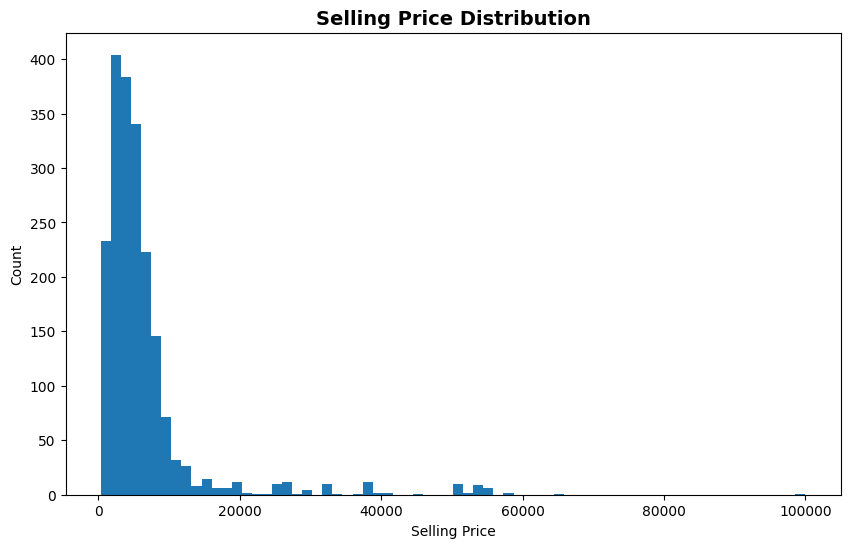

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['selling_price'], bins=70)
plt.title('Selling Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.show()

# Exploratory Data Analysis

###Numerik

In [22]:
num = df.select_dtypes(include=['int64', 'float64'])

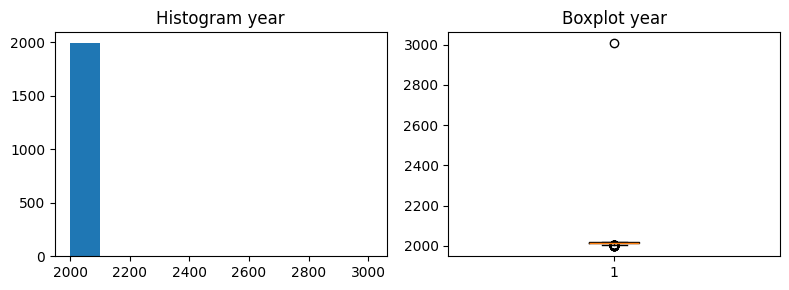

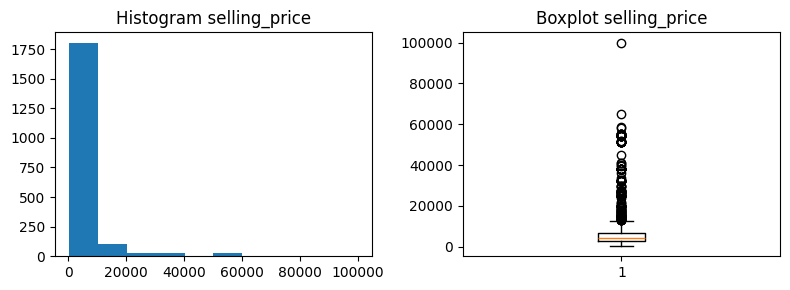

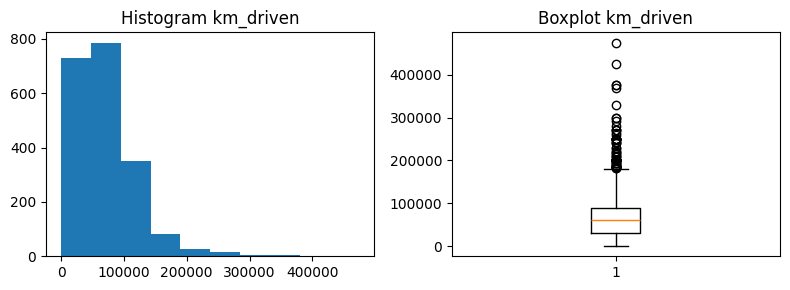

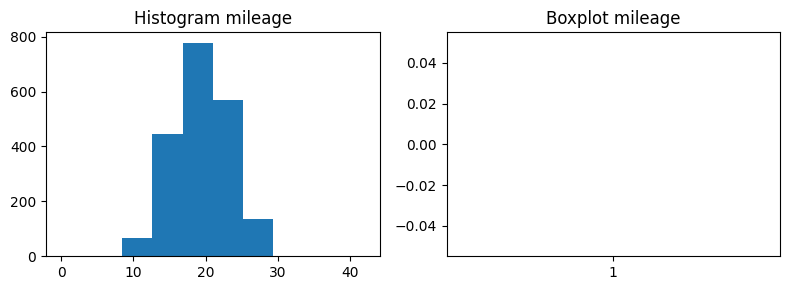

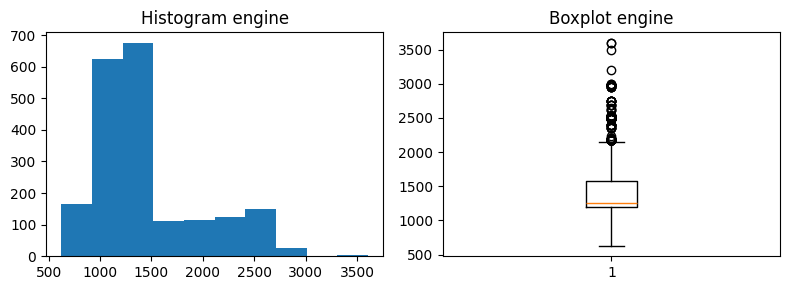

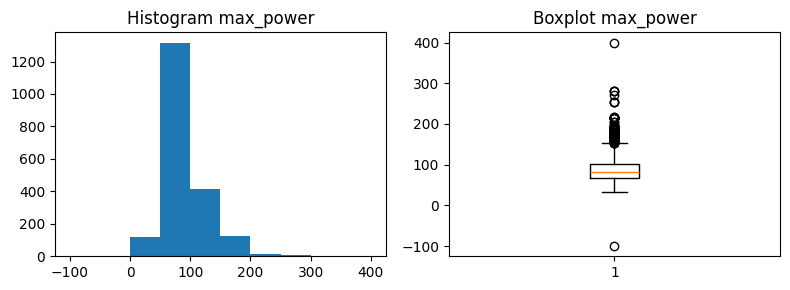

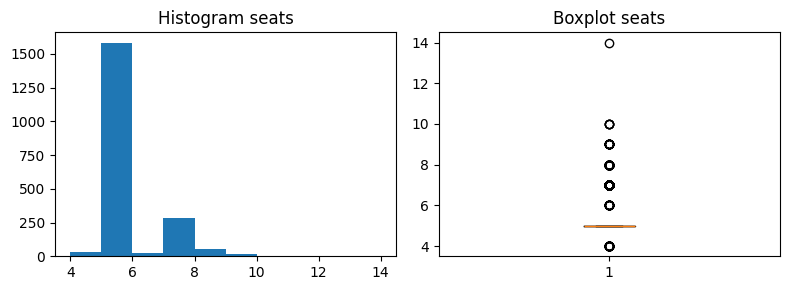

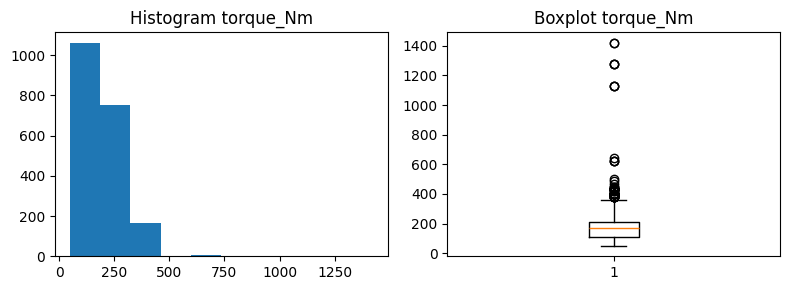

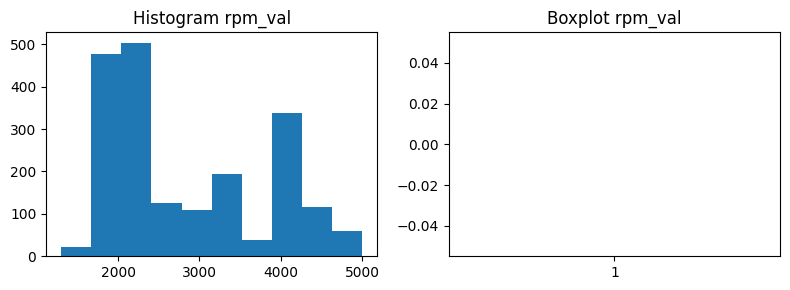

In [23]:
for col in num.columns:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].hist(df[col], bins=10)
    axes[0].set_title(f'Histogram {col}')
    axes[1].boxplot(df[col], vert=True)
    axes[1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

In [24]:
import pandas as pd
import numpy as np

def outlier_summary(df):
    num_cols = df.select_dtypes(include=[np.number]).columns

    results = []

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        count_outliers = outliers.shape[0]
        total = df[col].shape[0]
        percentage = (count_outliers / total) * 100

        results.append({
            'Feature': col,
            'Total Data': total,
            'Outlier Count': count_outliers,
            'Outlier Percentage (%)': round(percentage, 2)
        })

    return pd.DataFrame(results).sort_values(by='Outlier Percentage (%)', ascending=False)



In [25]:
outlie = outlier_summary(df)
outlie

,Feature,Total Data,Outlier Count,Outlier Percentage (%)
6,seats,1996,415,20.79
4,engine,1996,301,15.08
1,selling_price,1996,143,7.16
5,max_power,1996,135,6.76
7,torque_Nm,1996,88,4.41
2,km_driven,1996,61,3.06
0,year,1996,31,1.55
3,mileage,1996,3,0.15
8,rpm_val,1996,0,0.00


In [26]:
num.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_Nm,rpm_val
count,1996.000000,1996.000000,1996.000000,1994.000000,1996.000000,1996.000000,1996.000000,1996.000000,1984.000000
mean,2014.545090,6494.600286,68744.713427,19.433887,1462.316132,91.844486,5.407816,181.305574,2884.597278
std,22.616437,8320.662825,49974.828126,3.960117,500.140232,36.129822,0.949881,111.595498,956.148996
min,1999.000000,350.000000,0.000000,0.000000,624.000000,-100.000000,4.000000,48.000000,1300.000000
25%,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,2000.000000
50%,2015.000000,4500.000000,60000.000000,19.335000,1248.000000,82.000000,5.000000,170.000000,2400.000000
75%,2017.000000,6750.000000,90000.000000,22.320000,1582.000000,102.000000,5.000000,213.000000,4000.000000
max,3011.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000,1421.964250,5000.000000


Terdapat beberapa data yang inkonsisten atau memiliki nilai ekstrim pada data numerik

* year tidak mungkin > 2026
* max_power gk mungkin negatif
* nilai outlier torque nm sangat tinggi
* proporsi outlier seats tinggi

In [27]:
df = df[df['year'] <= 2026]
df = df[df['max_power'] > 0]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1994 entries, 0 to 1997
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1994 non-null   object 
 1   year               1994 non-null   int64  
 2   selling_price      1994 non-null   float64
 3   km_driven          1994 non-null   int64  
 4   Region             1994 non-null   object 
 5   State or Province  1994 non-null   object 
 6   City               1994 non-null   object 
 7   fuel               1994 non-null   object 
 8   seller_type        1994 non-null   object 
 9   transmission       1994 non-null   object 
 10  owner              1994 non-null   object 
 11  mileage            1992 non-null   float64
 12  engine             1994 non-null   int64  
 13  max_power          1994 non-null   float64
 14  seats              1994 non-null   int64  
 15  sold               1994 non-null   object 
 16  torque_Nm          1994 non-n

### Objek

In [29]:
objek = df.select_dtypes(include=['object'])

In [30]:
for col in objek.columns:
  print(objek[col].value_counts())
  print("--------------------------------------")

name
Maruti        576
Hyundai       360
Mahindra      184
Tata          184
Toyota        120
Ford          115
Honda         114
Renault        54
Chevrolet      49
Volkswagen     45
Skoda          35
BMW            27
Volvo          22
Datsun         21
Nissan         19
Jaguar         16
Mercedes       12
Lexus          10
Fiat            8
Jeep            7
Audi            7
Isuzu           3
Force           2
Mitsubishi      1
Land            1
Daewoo          1
MG              1
Name: count, dtype: int64
--------------------------------------
Region
Central    604
West       505
East       482
South      401
N/A          2
Name: count, dtype: int64
--------------------------------------
State or Province
California              222
Texas                   135
New York                123
Illinois                119
Florida                 107
Michigan                 82
Washington               78
Ohio                     74
Pennsylvania             65
Indiana                  60

In [31]:
df['transmission'].unique()

array(['Manual', 'Automatic', ''], dtype=object)

In [32]:
dfc=df[df['Region']=='N/A']
dfc

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,rpm_val
727,Maruti,2013,6000.0,60000,N/A,Illinois,Chicago,Diesel,Individual,Manual,First_Owner,20.77,1248,88.8,7,Y,200.0,1750.0
1467,Mahindra,2013,3000.0,120000,N/A,Illinois,Chicago,Diesel,Individual,Manual,Second_Owner,17.21,1493,100.0,7,Y,240.0,2200.0


In [33]:
df['Region']=df['Region'].replace({'N/A': 'Central'})

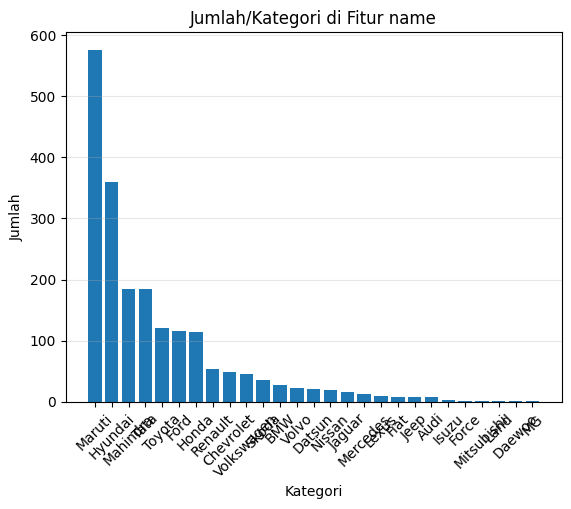

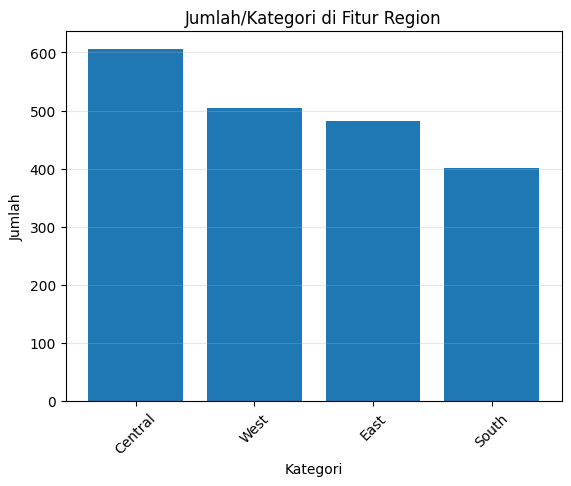

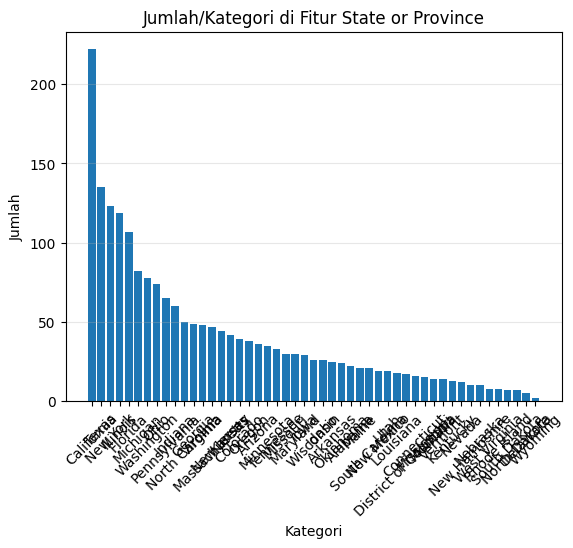

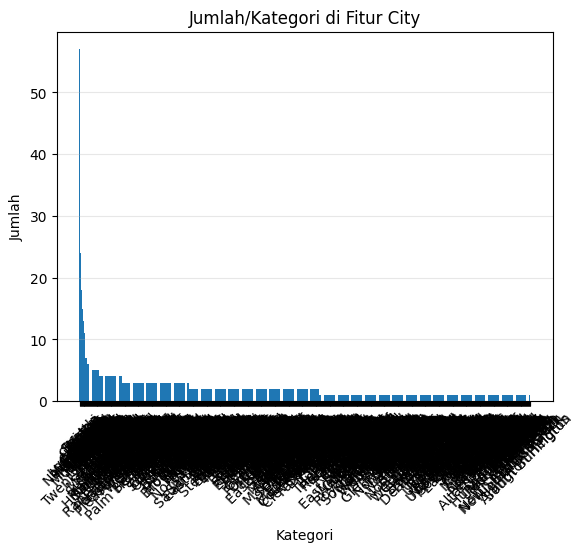

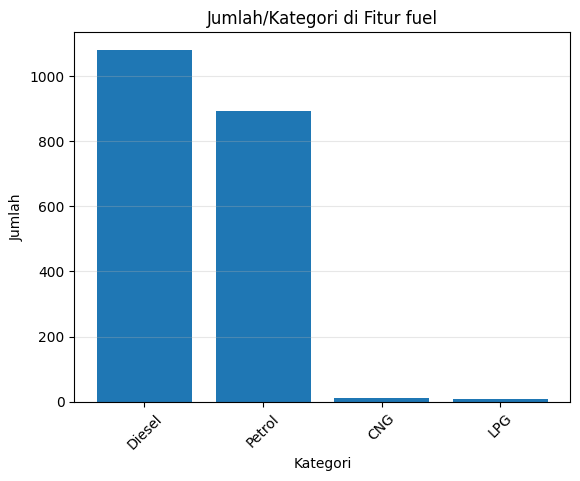

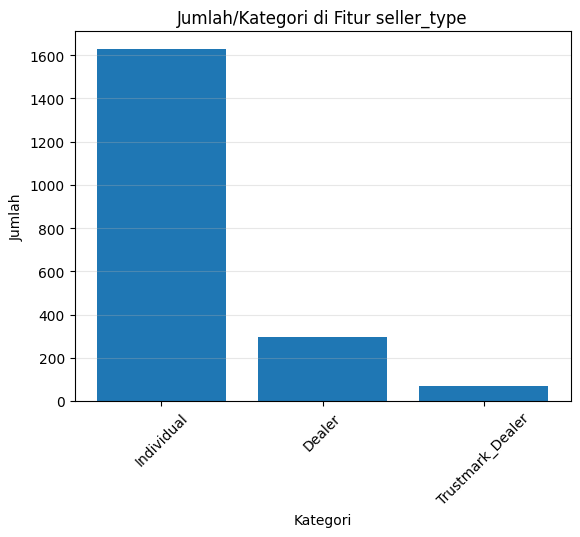

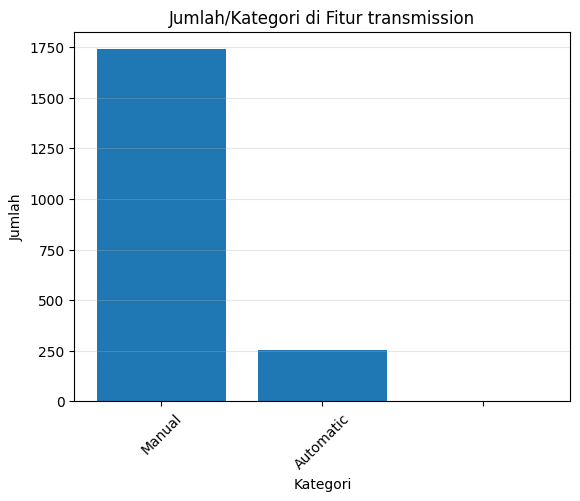

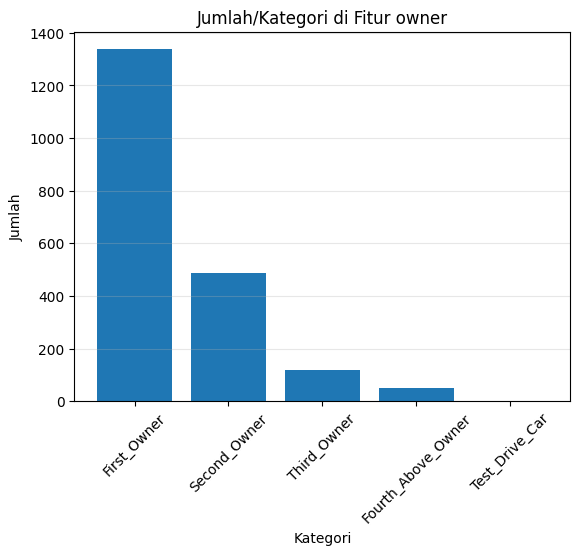

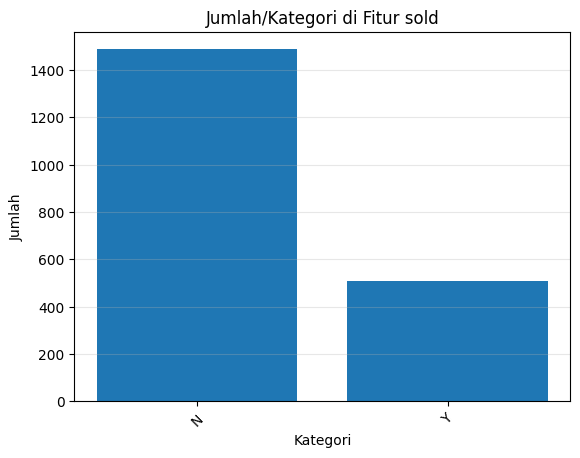

In [34]:
for col in objek.columns:

  counts = df[col].value_counts()
  plt.bar(counts.index, counts.values)
  plt.title(f"Jumlah/Kategori di Fitur {col}")
  plt.xlabel("Kategori")
  plt.ylabel("Jumlah")
  plt.grid(axis='y', alpha=0.3)
  plt.xticks(rotation=45)
  plt.show()

In [35]:
df = df.drop(columns=['City'])

## Correlation Analysis

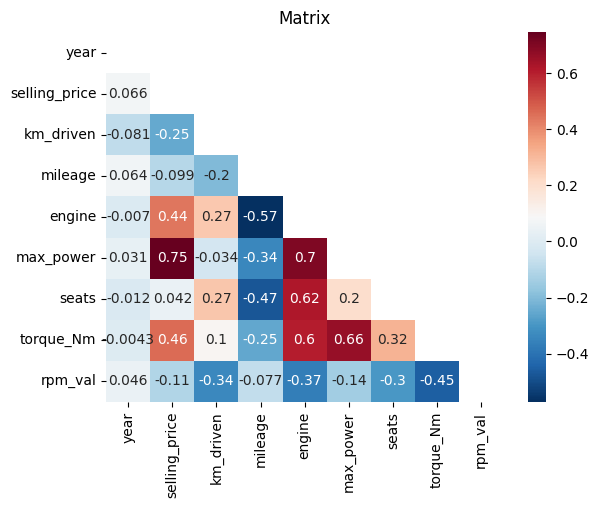

In [36]:
import seaborn as sns
corr = num.corr()
corrl = corr.loc[corr.index, corr.index]
mask1=np.triu(np.ones_like(corrl, dtype=bool))
sns.heatmap(corr.loc[corr.index, corr.index],cmap='RdBu_r',annot=True,mask=mask1)
plt.title("Matrix")
plt.show()



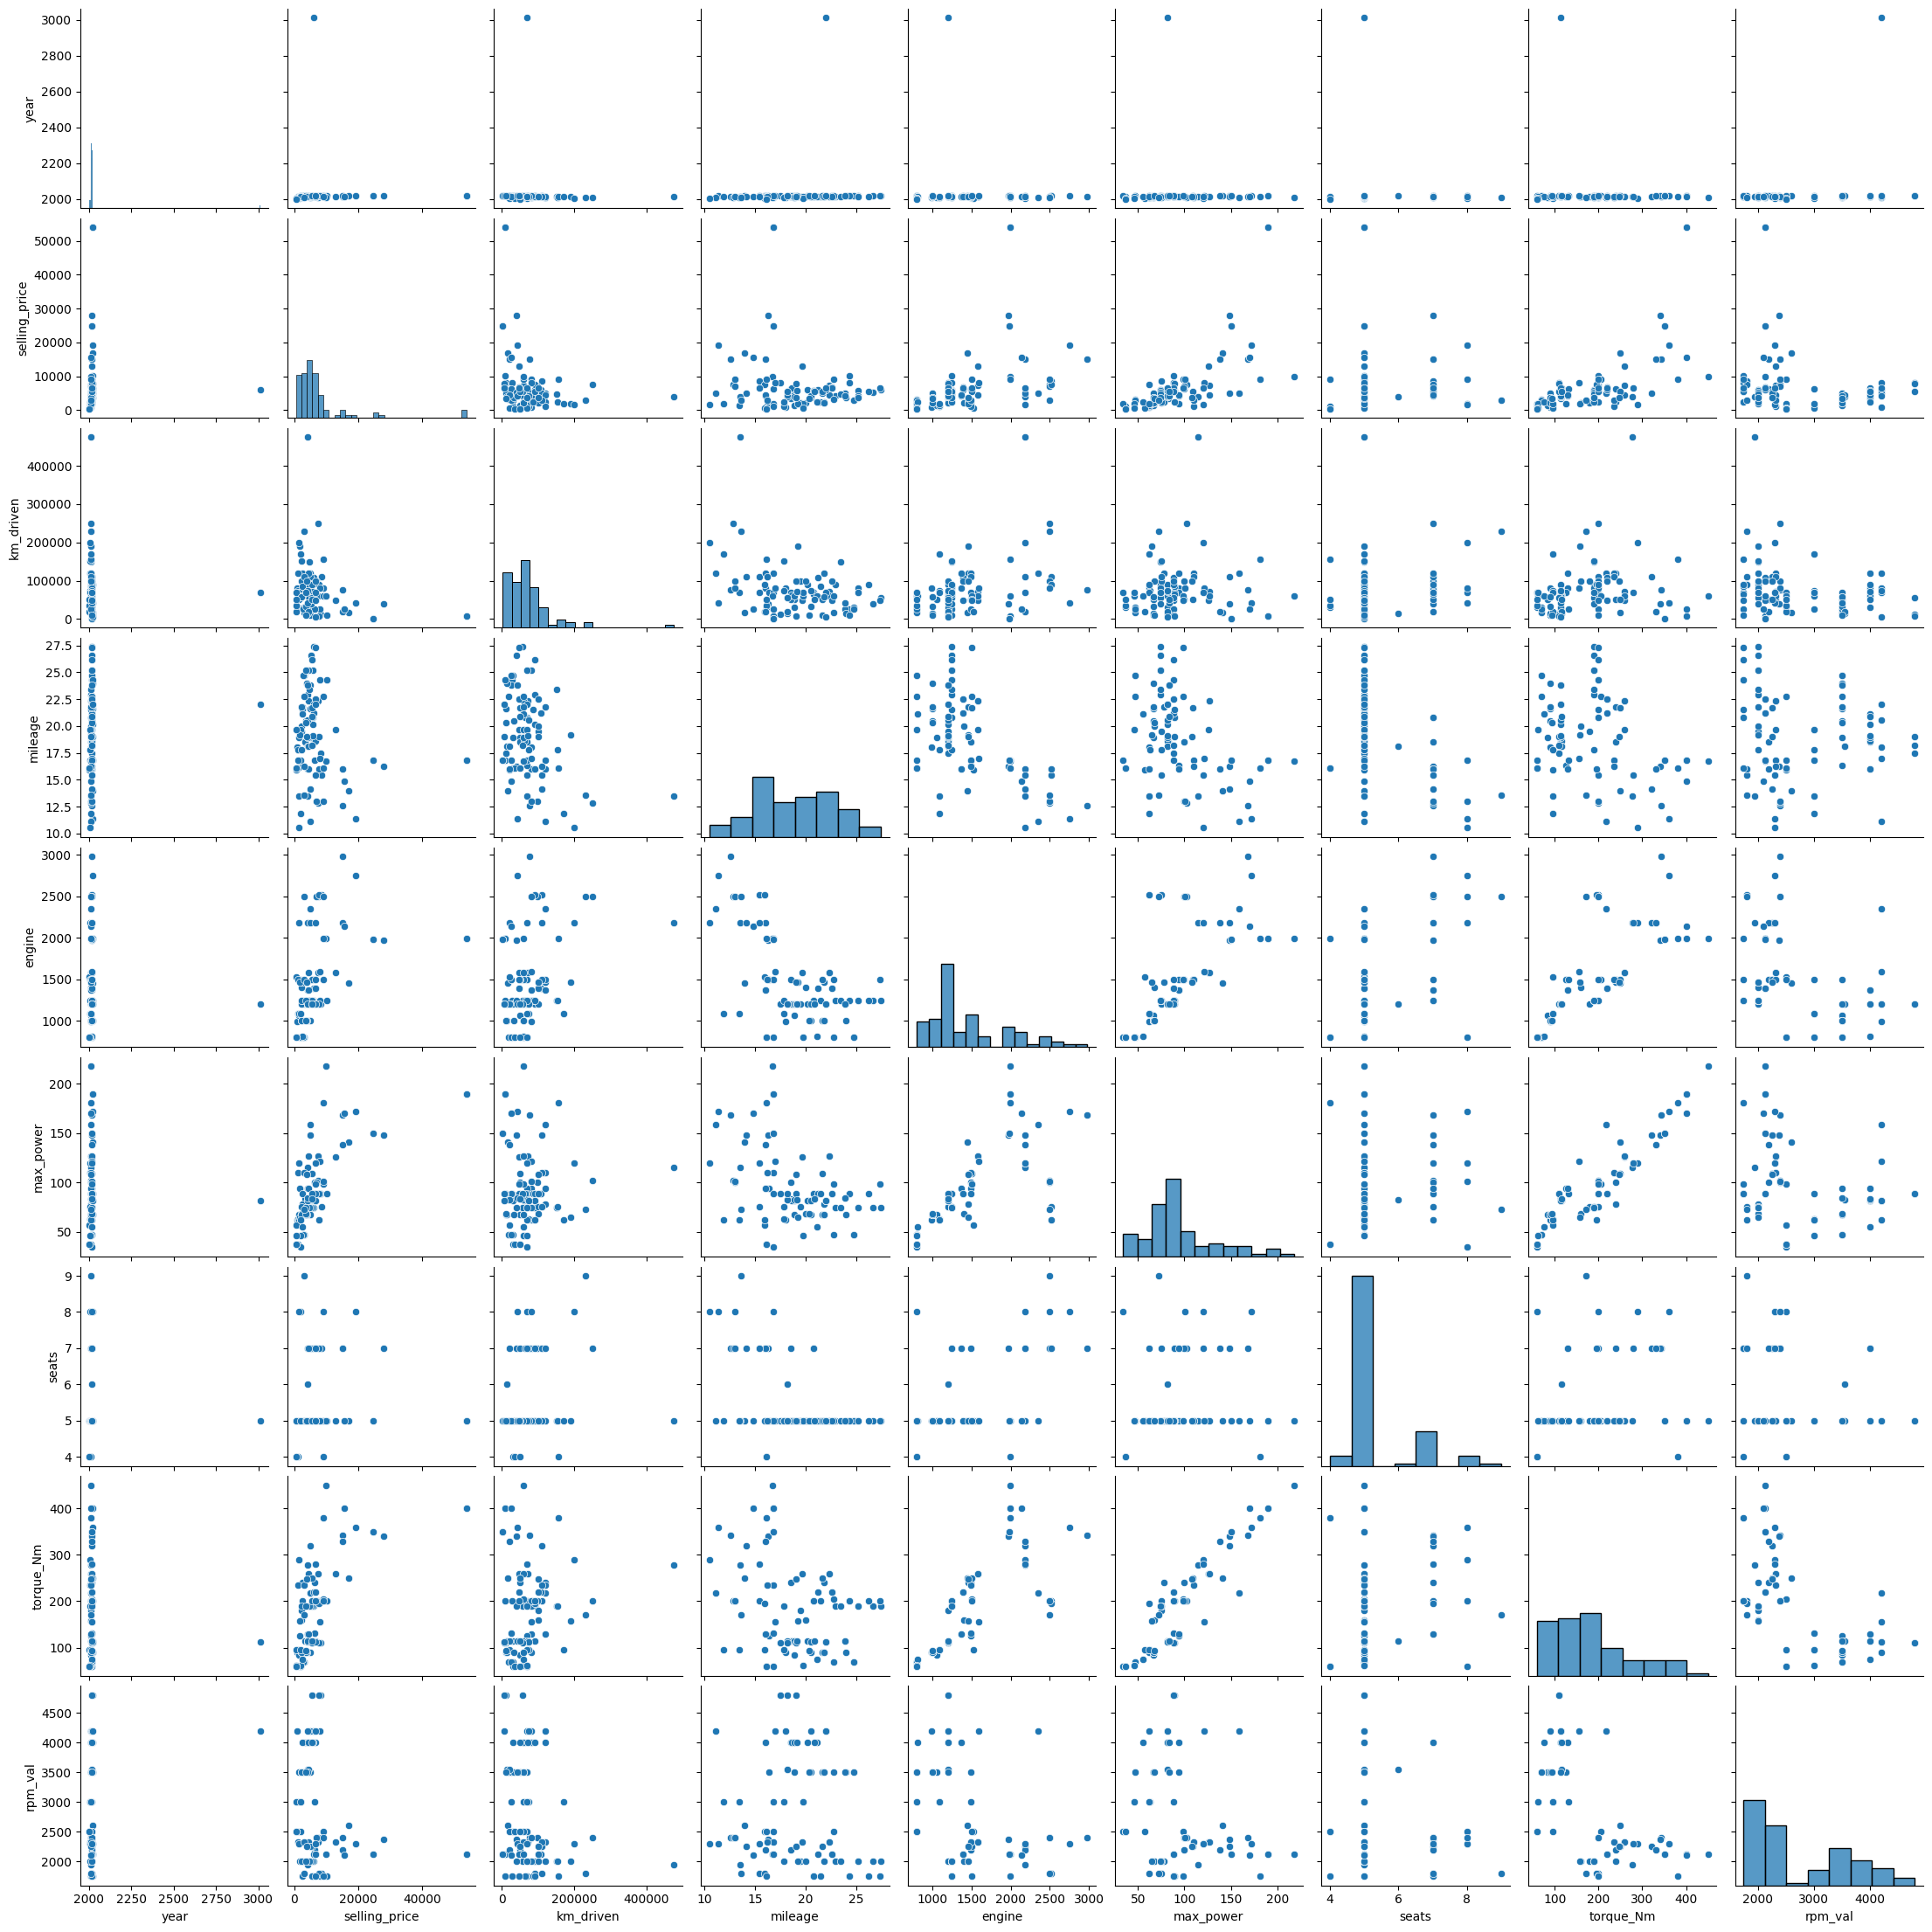

In [37]:
sns.pairplot(num.sample(100))
plt.show()

In [38]:
objek=['name', 'Region', 'State or Province', 'fuel', 'seller_type',
       'transmission', 'owner', 'sold']

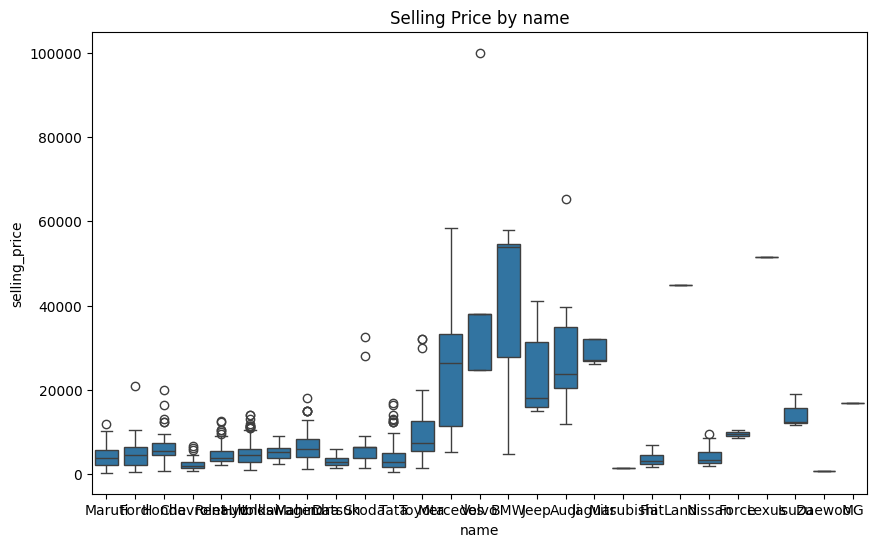

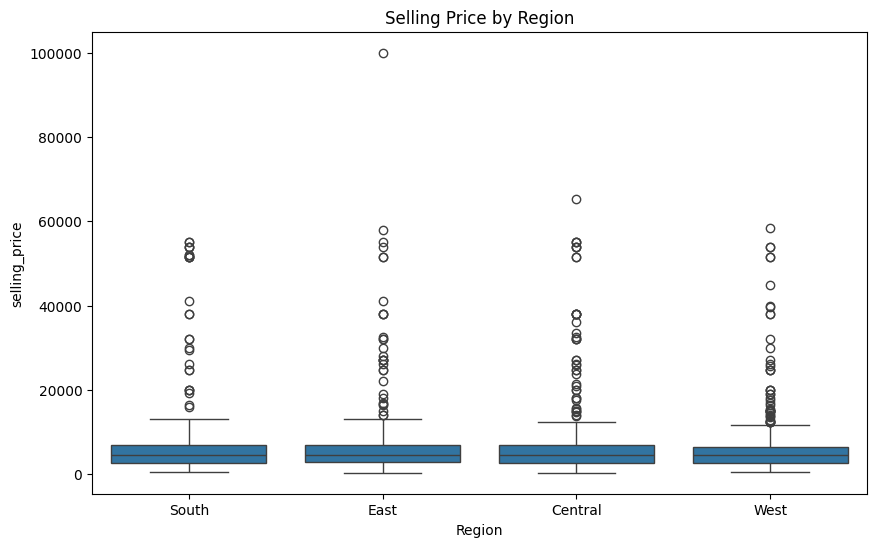

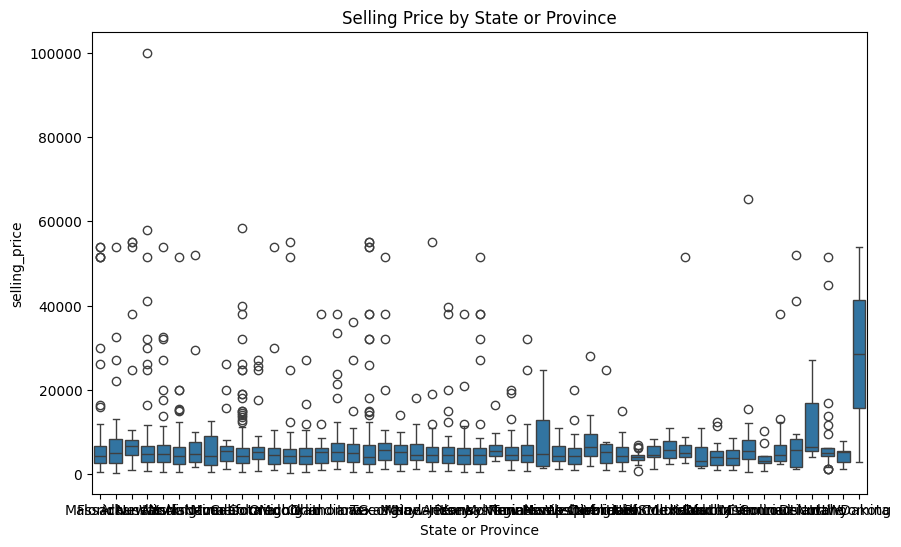

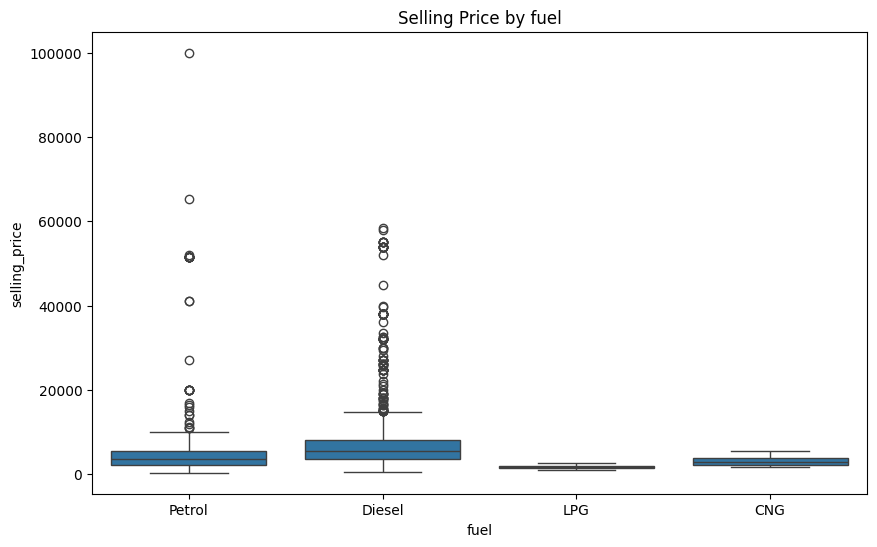

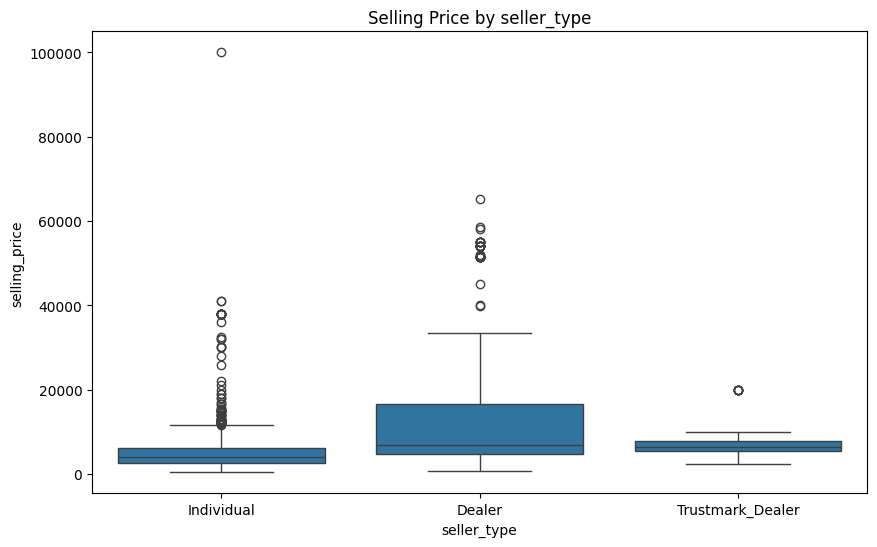

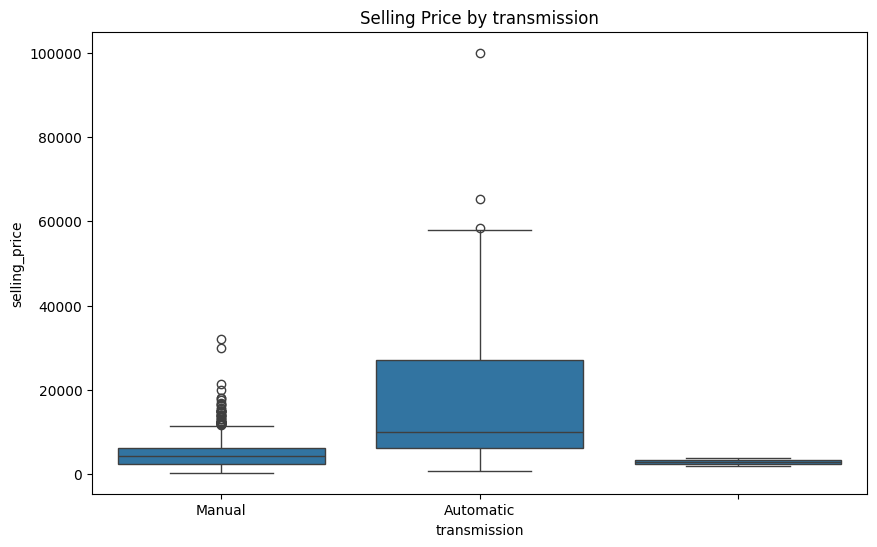

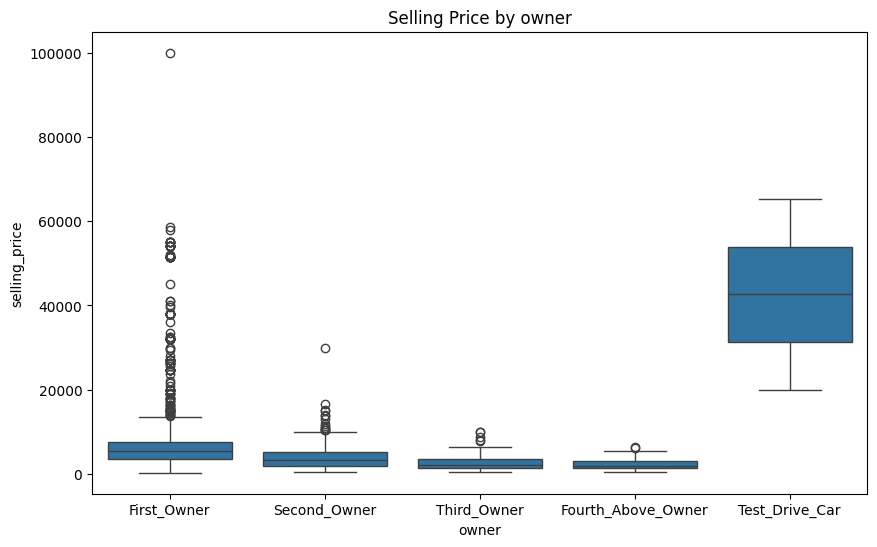

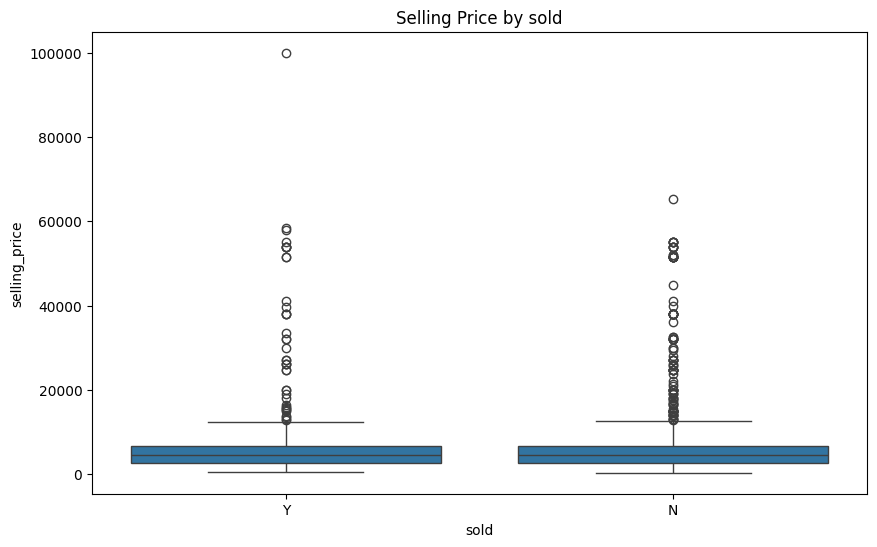

In [39]:
for c in objek:
  plt.figure(figsize=(10,6))
  sns.boxplot(x=c, y='selling_price', data=df)
  plt.title(f'Selling Price by {c}')
  plt.show()

# Split

In [40]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['selling_price'])
y=df['selling_price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Impute & normalization

In [41]:
x_train['transmission']=x_train['transmission'].replace({'': 'Manual'})
x_test['transmission']=x_test['transmission'].replace({'': 'Manual'})

In [42]:
x_train['rpm_val']= x_train['rpm_val'].fillna(x_train['rpm_val'].median())
x_test['rpm_val']= x_test['rpm_val'].fillna(x_test['rpm_val'].median())

In [43]:
x_train['mileage']= x_train['mileage'].fillna(x_train['mileage'].median())
x_test['mileage']= x_test['mileage'].fillna(x_test['mileage'].median())

In [44]:
x_train['km_driven']=np.log1p(x_train['km_driven'])
x_test['km_driven']=np.log1p(x_test['km_driven'])

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1994 entries, 0 to 1997
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1994 non-null   object 
 1   year               1994 non-null   int64  
 2   selling_price      1994 non-null   float64
 3   km_driven          1994 non-null   int64  
 4   Region             1994 non-null   object 
 5   State or Province  1994 non-null   object 
 6   fuel               1994 non-null   object 
 7   seller_type        1994 non-null   object 
 8   transmission       1994 non-null   object 
 9   owner              1994 non-null   object 
 10  mileage            1992 non-null   float64
 11  engine             1994 non-null   int64  
 12  max_power          1994 non-null   float64
 13  seats              1994 non-null   int64  
 14  sold               1994 non-null   object 
 15  torque_Nm          1994 non-null   float64
 16  rpm_val            1982 non-n

In [46]:
y_train=np.log1p(y_train)
y_test=np.log1p(y_test)

In [47]:
df['selling_price'].describe()

,selling_price
count,1994.000000
mean,6497.177618
std,8324.178819
min,350.000000
25%,2750.000000
50%,4500.000000
75%,6750.000000
max,100000.000000


In [48]:
y_train.describe()

,selling_price
count,1595.000000
mean,8.386762
std,0.807622
min,5.860786
25%,7.919720
50%,8.412055
75%,8.787373
max,11.512935


## Winsorise outlier

In [49]:
from scipy.stats.mstats import winsorize

x_train['torque_Nm'] = winsorize(x_train['torque_Nm'], limits=[0.05, 0.05])
x_test['torque_Nm'] = winsorize(x_test['torque_Nm'], limits=[0.05, 0.05])
x_train['seats'] = winsorize(x_train['seats'], limits=[0.05, 0.05])
x_test['seats'] = winsorize(x_test['seats'], limits=[0.05, 0.05])

#Feature Engineering

feature dgn outlier > 3% pakai robust scaler
yang lain pk standard scaler

## Scaling

In [50]:
x_train.columns

Index(['name', 'year', 'km_driven', 'Region', 'State or Province', 'fuel',
       'seller_type', 'transmission', 'owner', 'mileage', 'engine',
       'max_power', 'seats', 'sold', 'torque_Nm', 'rpm_val'],
      dtype='object')

In [51]:
num.columns

Index(['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power',
       'seats', 'torque_Nm', 'rpm_val'],
      dtype='object')

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder

many_outlie = ['seats', 'engine', 'max_power','torque_Nm']
less_outlie = ['km_driven', 'year','mileage','rpm_val']

scaler1 = StandardScaler()
x_train[less_outlie] = scaler1.fit_transform(x_train[less_outlie])
x_test[less_outlie] = scaler1.transform(x_test[less_outlie])

scaler2 = RobustScaler()
x_train[many_outlie] = scaler2.fit_transform(x_train[less_outlie])
x_test[many_outlie] = scaler2.transform(x_test[less_outlie])


## Encoding

In [53]:
for col in objek:
  print(f'Feature Name: {col}')
  print(f'number of unique Values: {df[col].nunique()}')
  print("+++")
  print(df[col].value_counts())
  print("--------------------------------------")

Feature Name: name
number of unique Values: 27
+++
name
Maruti        576
Hyundai       360
Mahindra      184
Tata          184
Toyota        120
Ford          115
Honda         114
Renault        54
Chevrolet      49
Volkswagen     45
Skoda          35
BMW            27
Volvo          22
Datsun         21
Nissan         19
Jaguar         16
Mercedes       12
Lexus          10
Fiat            8
Jeep            7
Audi            7
Isuzu           3
Force           2
Mitsubishi      1
Land            1
Daewoo          1
MG              1
Name: count, dtype: int64
--------------------------------------
Feature Name: Region
number of unique Values: 4
+++
Region
Central    606
West       505
East       482
South      401
Name: count, dtype: int64
--------------------------------------
Feature Name: State or Province
number of unique Values: 49
+++
State or Province
California              222
Texas                   135
New York                123
Illinois                119
Florida        

In [54]:
#freq
x_train['name'] = x_train['name'].map(x_train['name'].value_counts(normalize=True))
x_train['State or Province'] = x_train['State or Province'].map(x_train['State or Province'].value_counts(normalize=True))

x_test['name'] = x_test['name'].map(x_test['name'].value_counts(normalize=True))
x_test['State or Province'] = x_test['State or Province'].map(x_test['State or Province'].value_counts(normalize=True))


# Binary
x_train['transmission'] = x_train['transmission'].map({'Manual': 0, 'Automatic': 1})
x_test['transmission'] = x_test['transmission'].map({'Manual': 0, 'Automatic': 1})
x_train['sold'] = x_train['sold'].map({'Y': 1, 'N': 0})
x_test['sold'] = x_test['sold'].map({'Y': 1, 'N': 0})

# Ordinal
owner_map = {
    'First_Owner': 1,
    'Second_Owner': 2,
    'Third_Owner': 3,
    'Fourth_Above_Owner': 4,
    'Test_Drive_Car': 0
}

x_train['owner'] = x_train['owner'].map(owner_map)
x_test['owner'] = x_test['owner'].map(owner_map)

# One-hot
x_train = pd.get_dummies(x_train, columns=['fuel', 'seller_type', 'Region'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['fuel', 'seller_type', 'Region'], drop_first=True)

In [55]:
x_train.head()

,name,year,km_driven,State or Province,transmission,owner,mileage,engine,max_power,seats,...,torque_Nm,rpm_val,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark_Dealer,Region_East,Region_South,Region_West
1379,0.025705,-0.836071,0.351189,0.067712,0,4,1.499875,-0.8,1.094203,0.140315,...,-0.375,-1.195502,True,False,False,True,False,False,False,False
1830,0.095298,1.355437,-0.928585,0.011285,0,1,0.202818,0.8,0.163043,-0.999990,...,0.500,0.641553,False,False,True,True,False,False,False,True
678,0.010031,0.259683,-0.356909,0.049530,0,3,-0.014199,0.0,0.007246,-0.490615,...,0.750,1.166426,False,False,True,True,False,False,True,False
1084,0.006270,-0.288194,0.007458,0.015674,1,1,-1.957262,-0.4,-1.387681,-0.165957,...,-0.250,-0.933065,True,False,False,True,False,False,False,False
1559,0.095298,-0.562132,0.607926,0.049530,0,2,-1.028629,-0.6,-0.721014,0.369073,...,0.000,-0.408192,True,False,False,True,False,False,True,False


In [56]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1595 entries, 1379 to 1127
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          1595 non-null   float64
 1   year                          1595 non-null   float64
 2   km_driven                     1595 non-null   float64
 3   State or Province             1595 non-null   float64
 4   transmission                  1595 non-null   int64  
 5   owner                         1595 non-null   int64  
 6   mileage                       1595 non-null   float64
 7   engine                        1595 non-null   float64
 8   max_power                     1595 non-null   float64
 9   seats                         1595 non-null   float64
 10  sold                          1595 non-null   int64  
 11  torque_Nm                     1595 non-null   float64
 12  rpm_val                       1595 non-null   float64
 13  fuel_

1.B.  Buatlah 1 baseline model. Semua hidden layer wajib
menggunakan activation function bernama ReLU dan memiliki jumlah neuron minimal 2 kali lipat dari
dimensi input data. Model anda harus memiliki minimal 2 hidden layer. Lakukan training pada model
tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

# Modelling Using Keras - Baseline Model

In [57]:
x_train.shape

(1595, 21)

neuron minimal 2x21 = 42

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
model1 = Sequential([Dense(64, activation='relu', input_shape=(21,)),
                    Dense(42, activation='relu'),
                    Dense(1, activation='relu')])
print(model1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,181 (16.33 KB)

 Trainable params: 4,181 (16.33 KB)

 Non-trainable params: 0 (0.00 B)

None


## Training

In [59]:
model1.compile(optimizer='sgd',loss='mse',metrics=['mae'])

history1 = model1.fit(x_train,y_train,epochs=20,batch_size=30, validation_split=0.125, verbose=1)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.5410 - mae: 1.5429 - val_loss: 1.1486 - val_mae: 0.8133
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5936 - mae: 0.5838 - val_loss: 0.4390 - val_mae: 0.4796
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3377 - mae: 0.4474 - val_loss: 0.3229 - val_mae: 0.4218
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2951 - mae: 0.4121 - val_loss: 0.3694 - val_mae: 0.4821
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2558 - mae: 0.3848 - val_loss: 0.2707 - val_mae: 0.3767
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2223 - mae: 0.3550 - val_loss: 0.2675 - val_mae: 0.3836
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2160 - mae: 0.3509 - val_loss: 0.2535 - val_mae: 0.3757
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2053 - mae: 0.3417 - val_loss: 0.2201 - val_mae: 0.3370
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2025 - mae: 

## Evaluation

In [60]:
y_pred1 = model1.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [61]:
y_pred1 = np.expm1(y_pred1)
y_true1 = np.expm1(y_test)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae1= mean_absolute_error(y_true1, y_pred1)
mse1 = mean_squared_error(y_true1, y_pred1)
rmse1 = np.sqrt(mse1)
r21 = r2_score(y_true1, y_pred1)

print("MAE:", mae1)
print("MSE:", mse1)
print("RMSE:", rmse1)
print("R2 Score:", r21)

MAE: 2275.520312444931
MSE: 26565960.368247744
RMSE: 5154.217726119818
R2 Score: 0.6329315071175713


# Modified Modelling

1.C. Lakukan modifikasi pada model anda. Anda dapat mengubah
jumlah neuron dan layer ataupun activation function dari hidden layer. Anda juga dapat melakukan
hyperparameter fine-tuning pada model anda. Lakukan training pada modifikasi model anda dan
jelaskan alasan modifikasi yang anda lakukan.

In [63]:

model2 = Sequential([Dense(128, activation='elu', input_shape=(21,)),
                    Dense(64, activation='relu'),
                    Dense(42, activation='relu'),
                    Dense(1, activation='linear')])
print(model2.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 42)             │         2,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,845 (54.08 KB)

 Trainable params: 13,845 (54.08 KB)

 Non-trainable params: 0 (0.00 B)

None


In [64]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [65]:
model2.compile(optimizer='sgd',loss='mse',metrics=['mae'])

history2 = model2.fit(x_train,y_train,epochs=200,batch_size=10,
                    validation_split=0.125, verbose=1, callbacks=early_stop)

Epoch 1/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.9305 - mae: 1.1107 - val_loss: 0.3426 - val_mae: 0.4193
Epoch 2/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3310 - mae: 0.4487 - val_loss: 0.5762 - val_mae: 0.6262
Epoch 3/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2853 - mae: 0.4178 - val_loss: 0.1852 - val_mae: 0.3164
Epoch 4/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2279 - mae: 0.3754 - val_loss: 0.3056 - val_mae: 0.4263
Epoch 5/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2195 - mae: 0.3640 - val_loss: 0.1895 - val_mae: 0.3194
Epoch 6/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2396 - mae: 0.3810 - val_loss: 0.3044 - val_mae: 0.4321
Epoch 7/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1940 - mae: 0.3428 - val_loss: 0.1846 - val_mae: 0.3001
Epoch 8/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1853 - mae: 0.3343 - val_loss: 0.2902 - val_mae: 0.4055
Epoch 9/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [66]:
y_pred2 = model2.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [67]:
y_pred2 = np.expm1(y_pred2)
y_true2 = np.expm1(y_test)

In [68]:
mae2 = mean_absolute_error(y_true2, y_pred2)
mse2 = mean_squared_error(y_true2, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_true2, y_pred2)

print("MAE:", mae2)
print("MSE:", mse2)
print("RMSE:", rmse2)
print("R2 Score:", r22)

MAE: 2033.550622448455
MSE: 17923615.596521344
RMSE: 4233.629128362727
R2 Score: 0.7523449379273075


# Final Evaluation

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i^{pred} - y_i^{actual} \right|
$$

$$
MSE = \frac{1}{n} \sum (y_{pred} - y_{actual})^2
$$

Terjadi peningkatan pada metric di model modifikasi yaitu:

* MAE berkurang: Model lebih akurat
* RMSE berkurang: Model mampu menangani outlier dengan lebih baik
* R2 bertambah: Model dapat menjelaskan lebih besar variansi data
* train loss > Val loss: model tidak overfit, generalisasi baik